In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("../DATA/Clean_Dataset.csv", index_col=0)
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 27.5+ MB


In [4]:
df["stops"].value_counts()

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

In [5]:
df.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')

## Categorisation des Variables

In [6]:
data_categorisation = {
    "Qualitative":{
        "Normal":["airline","flight","source_city","destination_city"],
        "Ordinal":["departure_time","arrival_time","stops","class"]
    },
    "Quantitative":{
        "Discrete": ["days_left"],
        "Continuous":["duration","price"]
    }
}

In [7]:
for Qualitative_value_category in data_categorisation["Qualitative"]:
    for Qualitative_col in data_categorisation["Qualitative"][Qualitative_value_category]:
        if Qualitative_col == "flight":
            continue
        print(Qualitative_col,"Values :")
        print(list(df[Qualitative_col].value_counts().index))

airline Values :
['Vistara', 'Air_India', 'Indigo', 'GO_FIRST', 'AirAsia', 'SpiceJet']
source_city Values :
['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
destination_city Values :
['Mumbai', 'Delhi', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
departure_time Values :
['Morning', 'Early_Morning', 'Evening', 'Night', 'Afternoon', 'Late_Night']
arrival_time Values :
['Night', 'Evening', 'Morning', 'Afternoon', 'Early_Morning', 'Late_Night']
stops Values :
['one', 'zero', 'two_or_more']
class Values :
['Economy', 'Business']


In [8]:
df["flight"].str.split('-', expand=True).rename(columns={0: 'First', 1: 'Last'})["First"].value_counts()

First
UK    127859
AI     80892
6E     43120
G8     23173
I5     16098
SG      9011
Name: count, dtype: int64

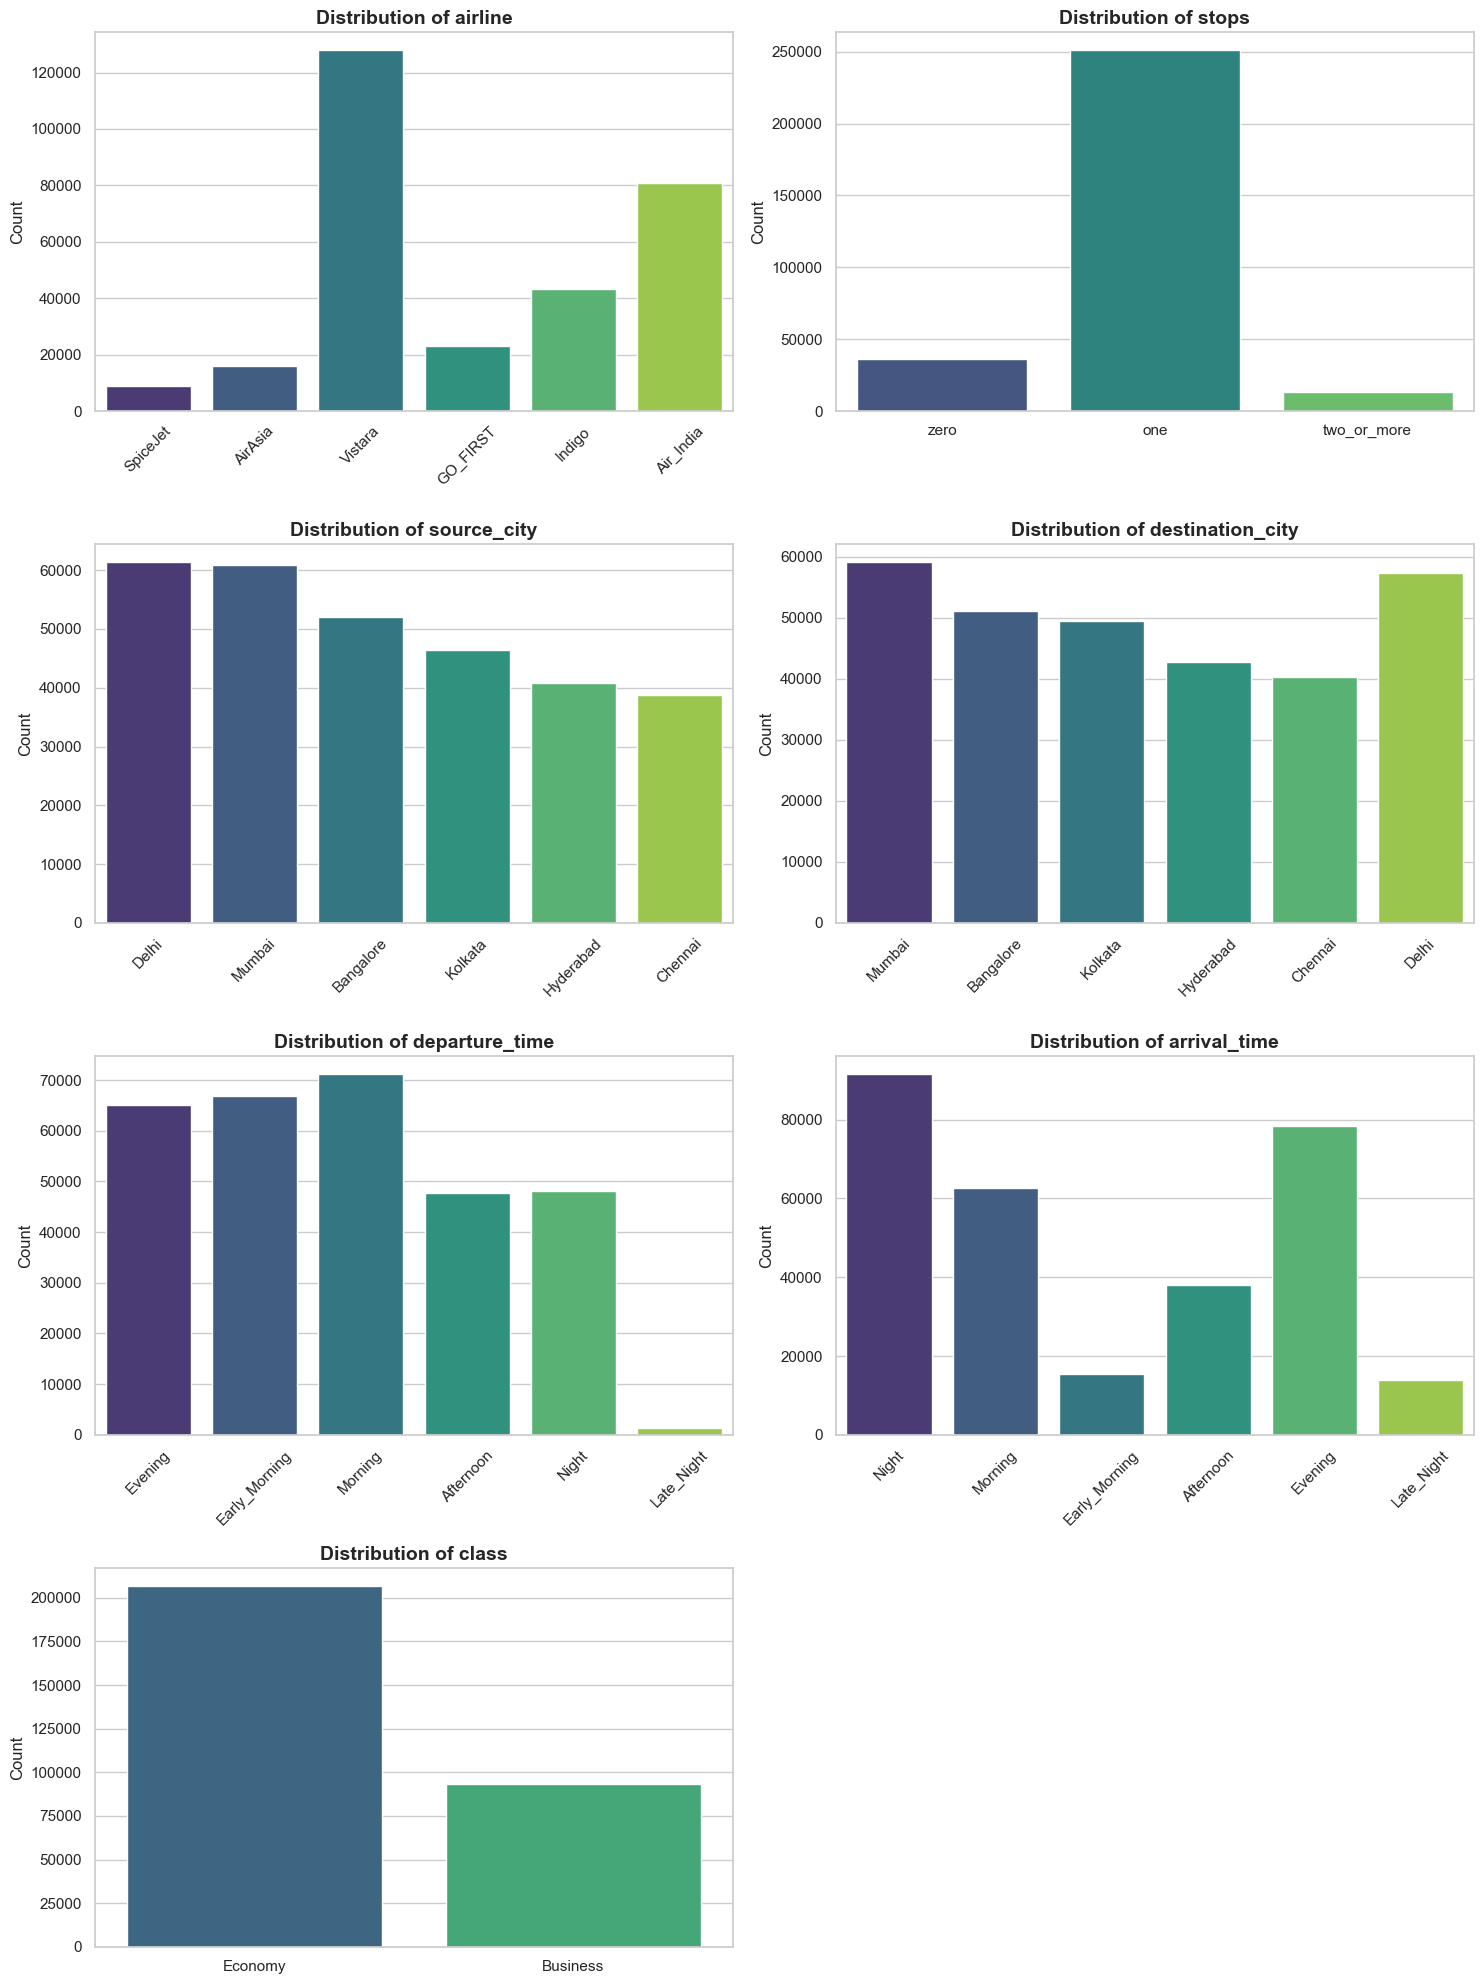

In [9]:
cols_to_plot = [
    "airline", "stops","source_city", "destination_city",
    "departure_time", "arrival_time",  "class"
]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.countplot(data=df, x=col, ax=axes[i], palette="viridis", hue=col, legend=False)
    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

    if df[col].nunique() > 3:
        axes[i].tick_params(axis='x', rotation=45)

fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

In [10]:
df[data_categorisation["Quantitative"]["Continuous"]].describe()

,duration,price
count,300153.000000,300153.000000
mean,12.221021,20889.660523
std,7.191997,22697.767366
min,0.830000,1105.000000
25%,6.830000,4783.000000
50%,11.250000,7425.000000
75%,16.170000,42521.000000
max,49.830000,123071.000000


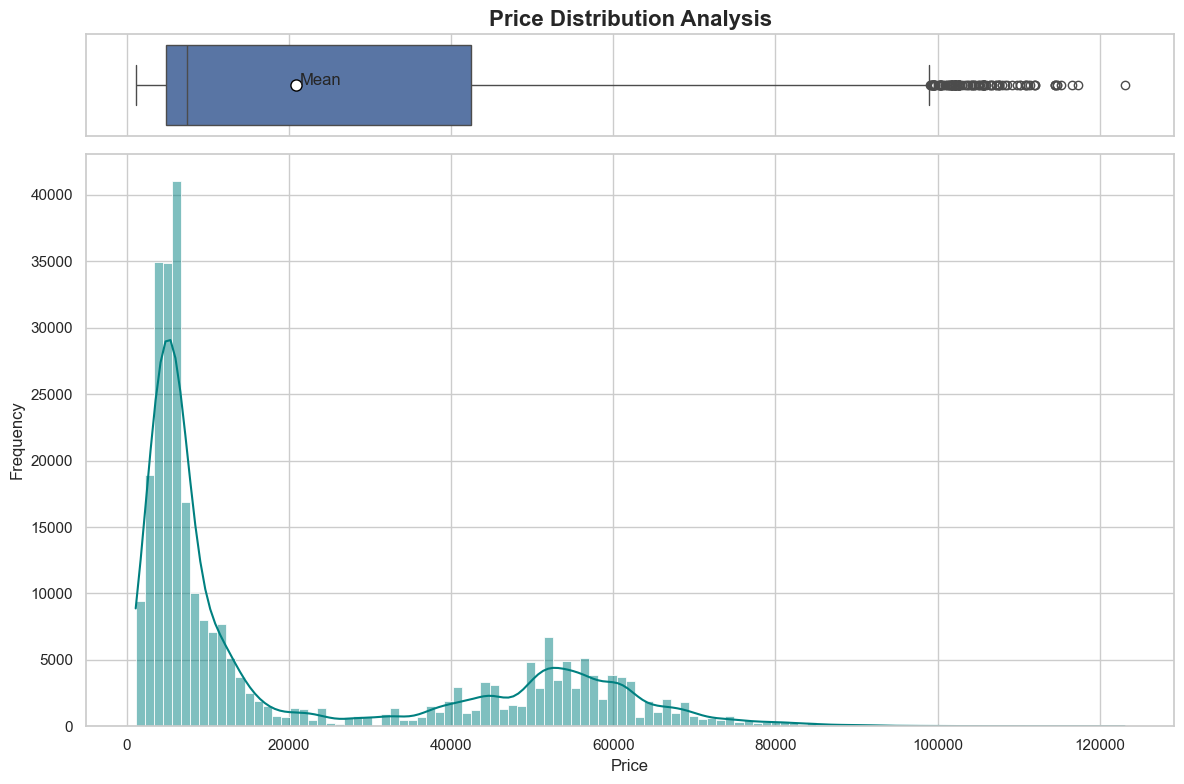

In [11]:
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True,gridspec_kw={"height_ratios": (.15, .85)},figsize=(12, 8))

sns.boxplot(x=df["price"], ax=ax_box, showmeans=True,
            meanprops={
                "marker": "o",
                "markerfacecolor": "white",
                "markeredgecolor": "black",
                "markersize": "8"
            })


sns.histplot(data=df, x="price", kde=True, ax=ax_hist, color="teal")

ax_box.set(xlabel='')
ax_box.set_title('Price Distribution Analysis', fontsize=16, fontweight='bold')
ax_hist.set_xlabel('Price', fontsize=12)
ax_hist.set_ylabel('Frequency', fontsize=12)

ax_box.text(x=df["price"].mean() * 1.02,y=0,s="Mean",)
plt.tight_layout()
plt.show()

In [12]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df["price"][df["price"] >= upper_bound].count()

np.int64(123)

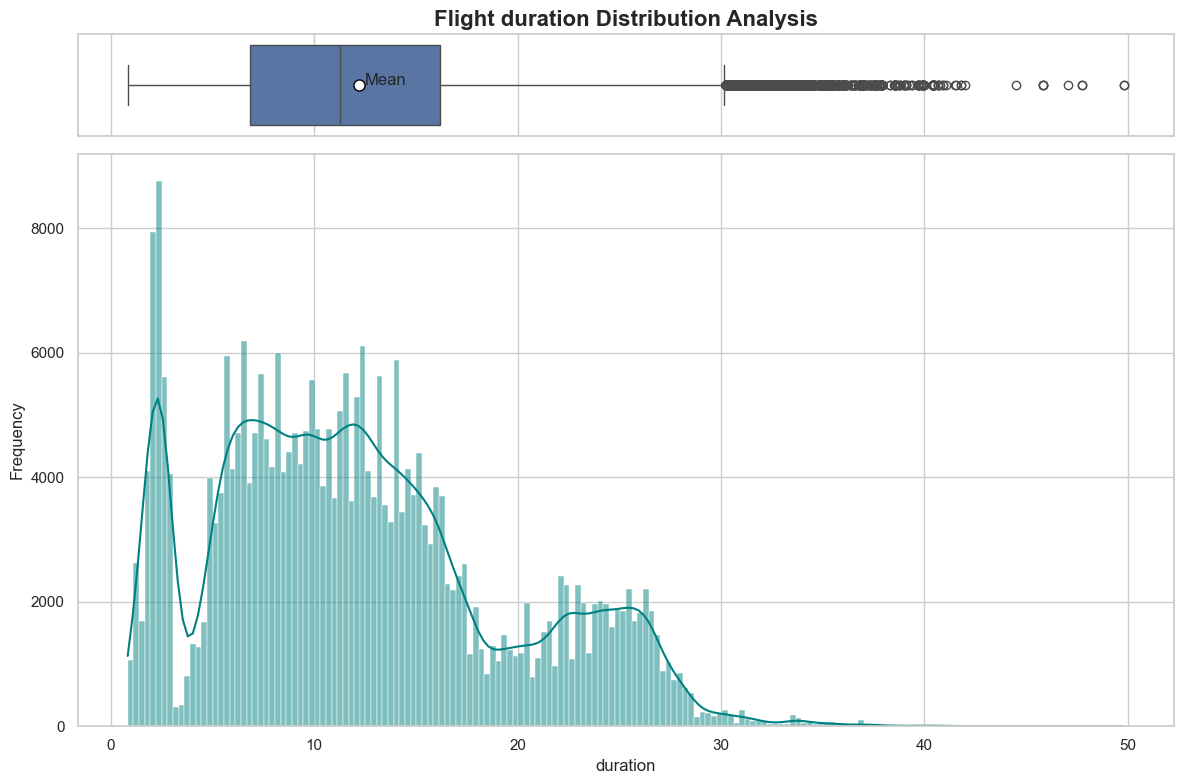

In [13]:
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True,gridspec_kw={"height_ratios": (.15, .85)},figsize=(12, 8))

sns.boxplot(x=df["duration"],ax=ax_box,showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "8"
    })

sns.histplot(data=df, x="duration", kde=True, ax=ax_hist, color="teal")

ax_box.set(xlabel='')
ax_box.set_title('Flight duration Distribution Analysis', fontsize=16, fontweight='bold')
ax_hist.set_xlabel('duration', fontsize=12)
ax_hist.set_ylabel('Frequency', fontsize=12)

ax_box.text(x=df["duration"].mean() * 1.02,y=0,s="Mean",)

plt.tight_layout()
plt.show()

In [14]:
Q1 = df["duration"].quantile(0.25)
Q3 = df["duration"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df["duration"][df["duration"] >= upper_bound].count()

np.int64(2110)

### Etude de relation entre la compagnie aérienne

In [16]:
airline_df =  df.groupby("airline").mean().sort_values("price", ascending=False).rename(columns={"price":"price_mean"})
airline_df

,price_mean
airline,
Vistara,30396.536302
Air_India,23507.019112
SpiceJet,6179.278881
GO_FIRST,5652.007595
Indigo,5324.216303
AirAsia,4091.072742


In [17]:
airline_df = airline_df.join(df.groupby("airline").sum().rename(columns={"price":"price_sum"}))
airline_df

,price_mean,price_sum
airline,,
Vistara,30396.536302,3886470735
Air_India,23507.019112,1901529790
SpiceJet,6179.278881,55681482
GO_FIRST,5652.007595,130973972
Indigo,5324.216303,229580207
AirAsia,4091.072742,65858089


### Si on suprime les valeurs abherents

In [18]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
df_bound = df[df["price"] < upper_bound]

In [19]:
airline_df = airline_df.join(df_bound.groupby("airline").mean().rename(columns={"price":"price_mean_bounded"}))
airline_df

,price_mean,price_sum,price_mean_bounded
airline,,,
Vistara,30396.536302,3886470735,30325.046361
Air_India,23507.019112,1901529790,23507.019112
SpiceJet,6179.278881,55681482,6179.278881
GO_FIRST,5652.007595,130973972,5652.007595
Indigo,5324.216303,229580207,5324.216303
AirAsia,4091.072742,65858089,4091.072742


In [20]:
airline_df = airline_df.join(df_bound.groupby("airline").sum().rename(columns={"price":"price_sum_bounded"}))
airline_df

,price_mean,price_sum,price_mean_bounded,price_sum_bounded
airline,,,,
Vistara,30396.536302,3886470735,30325.046361,3873600122
Air_India,23507.019112,1901529790,23507.019112,1901529790
SpiceJet,6179.278881,55681482,6179.278881,55681482
GO_FIRST,5652.007595,130973972,5652.007595,130973972
Indigo,5324.216303,229580207,5324.216303,229580207
AirAsia,4091.072742,65858089,4091.072742,65858089


### nombre d’escales vs prix 

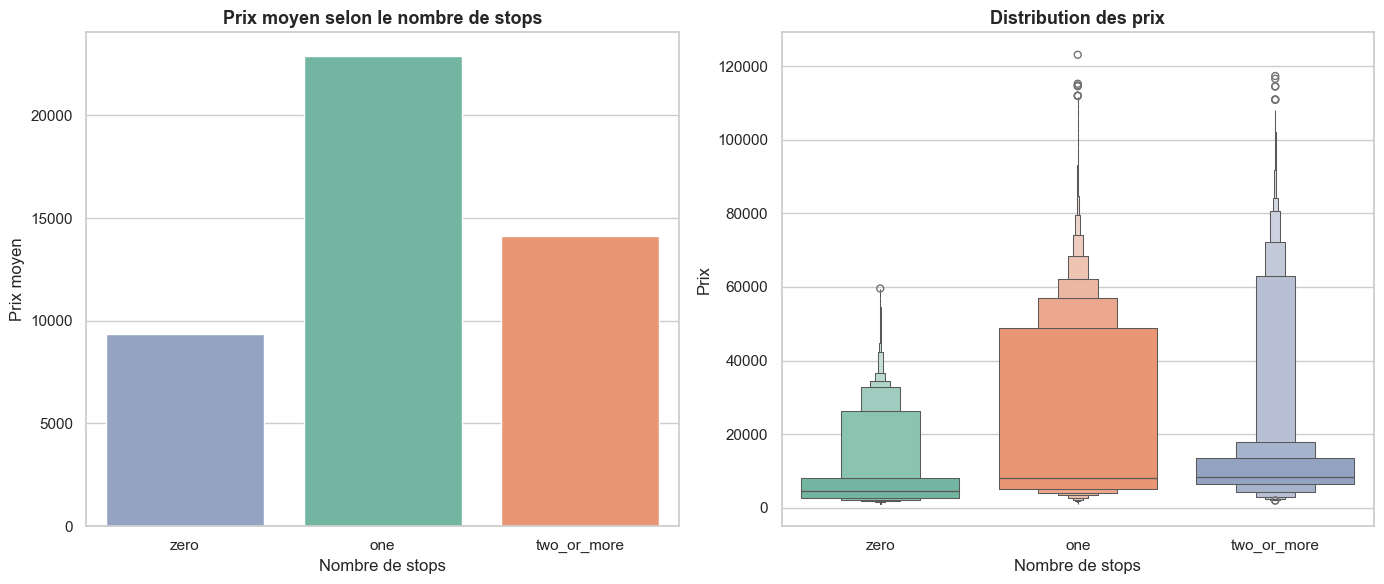

In [37]:
Stop_by_prix = df.groupby(['stops'])['price'].mean()
plt.figure(figsize=(14,6))

# Palette de couleurs
palette = "Set2"
order = ['zero', 'one', 'two_or_more']

# 1. Barplot
plt.subplot(1, 2, 1)
sns.barplot(x= Stop_by_prix.index, y= Stop_by_prix.values,
            palette=palette,
            hue=Stop_by_prix.index,
            order=order,
            legend=False)
plt.title("Prix moyen selon le nombre de stops", fontsize=13, weight='bold')
plt.xlabel("Nombre de stops")
plt.ylabel("Prix moyen")

# 2. Boxenplot
plt.subplot(1, 2, 2)
sns.boxenplot(data=df, x='stops', y='price', palette=palette, hue='stops')
plt.title("Distribution des prix", fontsize=13, weight='bold')
plt.xlabel("Nombre de stops")
plt.ylabel("Prix")

# Ajustement des marges
plt.tight_layout()

plt.show()

### Formulation et test d’hypothèses

In [23]:
from scipy import stats

zero = df[df['stops'] == 'zero']['price']
one = df[df['stops'] == 'one']['price']
two_or_more = df[df['stops'] == 'two_or_more']['price']

# Test ANOVA
f_stat, p_value = stats.f_oneway(zero, one, two_or_more)

print("F-statistic:", f_stat)
print("p-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Le nombre de stops influence significativement le prix.")
else:
    print("Pas d'effet significatif du nombre de stops.")


F-statistic: 6477.130362486214
p-value: 0.0
Le nombre de stops influence significativement le prix.
